# Reproducing Figure 1 plot

This notebook reproduces the workflow of evaluation of the ensembles on the mixed ID-OOD data. It combines the functionality of `evaluate_ensemble_ood.py` and `plot_results.py` into a single notebook. We avoid training the models here and instead load the saved ensemble weights. The workflow is as follows:

1. load the CIFAR-10 test data exactly as in `evaluate_ensemble_ood.py`
2. optionally mix in OOD data exactly as in that script (SVHN of CIFAR10C with different proportions and/or severities)
3. load the saved ensemble weights
4. evaluate the ensemble and save the result arrays
5. generate Figure 1 like plot using `plot_entropy_and_bounds_with_ood_bins_icml`


## 1. Configuration

Our main experiments used bash scripts and parsed arguments from terminal. We reproduce the same logic here with the CONFIG dictionary.


In [1]:
from pathlib import Path

# Change this to the root of your repository.
# It should contain the folder `experiments/`.
PROJECT_ROOT = Path('./')
PROJECT_ROOT = PROJECT_ROOT.resolve()  # Convert to absolute path

DISPLAY_ROOT_NAME = PROJECT_ROOT.name
def pretty_path(path, project_root=PROJECT_ROOT, display_root_name=DISPLAY_ROOT_NAME):
    path = Path(path)
    try:
        return str(Path(display_root_name) / path.relative_to(project_root))
    except ValueError:
        return str(path)

# Main experimental configuration
CONFIG = {
    'batch_size': 128,
    'num_models': 5,
    'ensemble_type': 'deep',      # supported here: 'deep'
    'data_transformation': 'raw_data',  # supported here: 'raw_data' or 'transf_data'
    'ood_fraction': 0.2,  # any value in [0, 1] is supported
    'ood_dataset': 'svhn',        # 'svhn' or 'cifar10c'
    'cifar10c_corruption': 'gaussian_noise',  # only for cifar10c
    'cifar10c_severity': 0,  # only for cifar10c, any value in [1, 5] is supported
}

# Seeds to match the training seed of the different ensembles
SEEDS_TO_EVALUATE = [0, 1, 2, 3, 4]

print('PROJECT_ROOT =', pretty_path(PROJECT_ROOT))
print('CONFIG =', CONFIG)
print('SEEDS_TO_EVALUATE =', SEEDS_TO_EVALUATE)

import warnings
warnings.filterwarnings("ignore")

PROJECT_ROOT = Position-Joint-Distribution-UQ
CONFIG = {'batch_size': 128, 'num_models': 5, 'ensemble_type': 'deep', 'data_transformation': 'raw_data', 'ood_fraction': 0.2, 'ood_dataset': 'svhn', 'cifar10c_corruption': 'gaussian_noise', 'cifar10c_severity': 0}
SEEDS_TO_EVALUATE = [0, 1, 2, 3, 4]


In [2]:
import os
import sys
import random
import numpy as np
import torch
from torch.utils.data import DataLoader, random_split
import matplotlib.pyplot as plt

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from experiments.modules.models import SimpleCNN
from experiments.modules.evaluation_functions import (
    evaluate_ensemble,
    evaluate_ensemble_performance,
)
from experiments.modules.dataset_utils import cifar10_loaders
from experiments.modules.plotting_functions import plot_entropy_and_bounds_with_ood_bins_icml

## 2. Helper functions

We add these functions here to showcase the logic in the main scripts.


In [3]:
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', DEVICE)

def set_seed(seed: int):
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    np.random.seed(seed)
    random.seed(seed)


def build_results_dir(config, averaged=False, seed=None):
    data_transformation = config['data_transformation']
    base = PROJECT_ROOT / 'experiments' / 'results' / 'cifar10'

    if config['ood_fraction'] > 0.0:
        if config['ood_dataset'] == 'cifar10c':
            root = (
                base
                / f"{config['ensemble_type']}_{data_transformation}"
                / config['ood_dataset']
                / f"num_models_{config['num_models']}"
                / f"frac_{config['ood_fraction']}"
                / f"sev_{config['cifar10c_severity']}"
            )
        elif config['ood_dataset'] == 'svhn':
            root = (
                base
                / f"{config['ensemble_type']}_{data_transformation}"
                / config['ood_dataset']
                / f"num_models_{config['num_models']}"
                / f"frac_{config['ood_fraction']}"
            )
        else:
            raise ValueError(f"Unsupported OOD dataset: {config['ood_dataset']}")
    else:
        root = (
            base
            / f"{config['ensemble_type']}_{data_transformation}"
            / 'normal'
            / f"num_models_{config['num_models']}"
        )

    if averaged:
        return root
    if seed is None:
        raise ValueError('seed must be provided when averaged=False')
    return root / f'ensemble_{seed}'


def build_ensemble_folder(config, seed):
    return (
        PROJECT_ROOT
        / 'experiments'
        / 'saved_models'
        / 'cifar10'
        / f"{config['ensemble_type']}_{config['data_transformation']}"
        / f'ensemble_{seed}'
    )


def load_test_loader_and_ood_flags(config):
    _, _, cifar10_test_loader = cifar10_loaders(config, data_transformation=config['data_transformation'])
    cifar10_test_dataset = cifar10_test_loader.dataset

    if config['ood_fraction'] > 0.0:
        from experiments.modules.dataset_utils import DatasetWithOODFlag

        num_id = int((1 - config['ood_fraction']) * len(cifar10_test_dataset))
        num_ood = len(cifar10_test_dataset) - num_id

        id_subset, _ = random_split(
            cifar10_test_dataset,
            [num_id, num_ood],
            generator=torch.Generator().manual_seed(42)
        )

        transform = cifar10_test_dataset.transform

        if config['ood_dataset'] == 'cifar10c':
            from experiments.modules.dataset_utils import CIFAR10C
            ood_data = CIFAR10C(
                root='data/cifar10c',
                corruption=config['cifar10c_corruption'],
                severity=config['cifar10c_severity'],
                transform=transform,
            )
        elif config['ood_dataset'] == 'svhn':
            from experiments.modules.dataset_utils import load_svhn_dataset
            ood_data = load_svhn_dataset(root='data/svhn', transform=transform)
        else:
            raise ValueError(f"Unsupported OOD dataset: {config['ood_dataset']}")

        ood_subset, _ = random_split(
            ood_data,
            [num_ood, len(ood_data) - num_ood],
            generator=torch.Generator().manual_seed(42)
        )

        id_subset = DatasetWithOODFlag(id_subset, is_ood=False)
        ood_subset = DatasetWithOODFlag(ood_subset, is_ood=True)
        mixed_test_dataset = torch.utils.data.ConcatDataset([id_subset, ood_subset])

        test_loader = DataLoader(
            mixed_test_dataset,
            batch_size=config['batch_size'],
            shuffle=False,
            num_workers=4,
            pin_memory=True,
        )

        is_ood = []
        for _, _, ood_flag in mixed_test_dataset:
            is_ood.append(ood_flag)
        is_ood = torch.tensor(is_ood)
    else:
        test_loader = cifar10_test_loader
        is_ood = torch.zeros(len(cifar10_test_dataset))

    return test_loader, is_ood


def load_ensemble_models(config, seed, device):
    ensemble_folder = build_ensemble_folder(config, seed)
    ensemble_models = []

    for i in range(config['num_models']):
        new_seed = seed + i
        set_seed(new_seed)
        model = SimpleCNN().to(device)
        weight_path = ensemble_folder / f'ensemble_model_{i}.pth'
        model.load_state_dict(torch.load(weight_path, map_location=device))
        model.eval()
        ensemble_models.append(model)

    return ensemble_models, ensemble_folder


def evaluate_one_seed(config, seed, test_loader, is_ood, device):
    ensemble_models, ensemble_folder = load_ensemble_models(config, seed, device)

    if config['ensemble_type'] in ['deep']:
        predictions, entropies, lower_bound, upper_bound, aleatoric = evaluate_ensemble(
            ensemble_models, test_loader, device
        )
        acc_per_model, ensemble_acc, acc_per_model_id, ensemble_acc_id = evaluate_ensemble_performance(
            ensemble_models, test_loader, device
        )
    else:
        raise ValueError(f"Ensemble type {config['ensemble_type']} not implemented in this notebook.")

    y_test = []
    for batch in test_loader:
        labels = batch[1]
        y_test.append(labels)
    y_test = torch.cat(y_test, dim=0).cpu()

    predictions = predictions.cpu()
    pred_labels = predictions.argmax(dim=-1)
    accuracy_per_sample = (pred_labels == y_test).float()
    true_class_probability = predictions[torch.arange(len(y_test)), y_test]
    max_class_probability = predictions[torch.arange(len(pred_labels)), pred_labels]

    result = {
        'seed': seed,
        'ensemble_folder': str(ensemble_folder),
        'entropies': entropies.numpy(),
        'lower_bound': lower_bound.numpy(),
        'upper_bound': upper_bound.numpy(),
        'aleatoric': aleatoric.numpy(),
        'accuracy_per_sample': accuracy_per_sample.numpy(),
        'true_class_probability': true_class_probability.numpy(),
        'max_class_probability': max_class_probability.numpy(),
        'acc_per_model': acc_per_model,
        'ensemble_acc': ensemble_acc,
        'acc_per_model_id': acc_per_model_id,
        'ensemble_acc_id': ensemble_acc_id,
        'is_ood': is_ood.numpy(),
    }
    return result


def save_result_arrays(results_dir, result, config):
    results_dir = Path(results_dir)
    results_dir.mkdir(parents=True, exist_ok=True)

    np.savez(
        results_dir / 'uncertainty_accuracy_vectors_no_order.npz',
        entropies=result['entropies'],
        lower_bound=result['lower_bound'],
        upper_bound=result['upper_bound'],
        aleatoric=result['aleatoric'],
        accuracy_per_sample=result['accuracy_per_sample'],
        true_class_probability=result['true_class_probability'],
        max_class_probability=result['max_class_probability'],
        is_ood=result['is_ood'],
    )

    np.savez(
        results_dir / 'accuracy_per_model.npz',
        acc_per_model=result['acc_per_model'],
        ensemble_acc=result['ensemble_acc'],
        acc_per_model_id=result['acc_per_model_id'],
        ensemble_acc_id=result['ensemble_acc_id'],
    )

    np.save(results_dir / 'config.npy', config)
    with open(results_dir / 'config.txt', 'w') as f:
        for key, value in config.items():
            f.write(f'{key}: {value}')


def average_seed_results(seed_results):
    avg = {
        'entropies': np.mean(np.array([r['entropies'] for r in seed_results]), axis=0),
        'lower_bound': np.mean(np.array([r['lower_bound'] for r in seed_results]), axis=0),
        'upper_bound': np.mean(np.array([r['upper_bound'] for r in seed_results]), axis=0),
        'aleatoric': np.mean(np.array([r['aleatoric'] for r in seed_results]), axis=0),
        'accuracy_per_sample': np.mean(np.array([r['accuracy_per_sample'] for r in seed_results]), axis=0),
        'true_class_probability': np.mean(np.array([r['true_class_probability'] for r in seed_results]), axis=0),
        'max_class_probability': np.mean(np.array([r['max_class_probability'] for r in seed_results]), axis=0),
        'acc_per_model': np.mean(np.array([r['acc_per_model'] for r in seed_results]), axis=0),
        'ensemble_acc': np.mean(np.array([r['ensemble_acc'] for r in seed_results]), axis=0),
        'acc_per_model_id': np.mean(np.array([r['acc_per_model_id'] for r in seed_results]), axis=0),
        'ensemble_acc_id': np.mean(np.array([r['ensemble_acc_id'] for r in seed_results]), axis=0),
        'is_ood': seed_results[0]['is_ood'],
    }
    return avg

Using device: cpu


## 3. Build the test loader
The test loader mixes some proportion of ID data (CIFAR10) with the OOD data (SVHN or CIFAR10C) according to the configuration. We also return a boolean array indicating which samples are OOD, which will be used for plotting later.


In [4]:
test_loader, is_ood = load_test_loader_and_ood_flags(CONFIG)
print('Number of test samples:', len(is_ood))
print('Number of OOD samples:', int(is_ood.sum().item()))
print('OOD fraction actually used:', float(is_ood.float().mean().item()))

Using raw data for CIFAR-10
Number of test samples: 10000
Number of OOD samples: 2000
OOD fraction actually used: 0.20000000298023224


## 4. Evaluate and save results for each seed

This reproduces the main evaluation loop from `evaluate_ensemble_ood.py`. For each seed, we load the ensemble models, evaluate on the test loader, and save the results.


In [5]:
seed_results = []

for seed in SEEDS_TO_EVALUATE:
    print(f'\nEvaluating ensemble seed {seed}')
    result = evaluate_one_seed(CONFIG, seed, test_loader, is_ood, DEVICE)
    seed_results.append(result)

    per_seed_dir = build_results_dir(CONFIG, averaged=False, seed=seed)
    save_result_arrays(per_seed_dir, result, CONFIG)

    print('Saved per-seed results to:', pretty_path(per_seed_dir))
    print('Ensemble folder used:', pretty_path(result['ensemble_folder']))


Evaluating ensemble seed 0
Saved per-seed results to: Position-Joint-Distribution-UQ\experiments\results\cifar10\deep_raw_data\svhn\num_models_5\frac_0.2\ensemble_0
Ensemble folder used: Position-Joint-Distribution-UQ\experiments\saved_models\cifar10\deep_raw_data\ensemble_0

Evaluating ensemble seed 1
Saved per-seed results to: Position-Joint-Distribution-UQ\experiments\results\cifar10\deep_raw_data\svhn\num_models_5\frac_0.2\ensemble_1
Ensemble folder used: Position-Joint-Distribution-UQ\experiments\saved_models\cifar10\deep_raw_data\ensemble_1

Evaluating ensemble seed 2
Saved per-seed results to: Position-Joint-Distribution-UQ\experiments\results\cifar10\deep_raw_data\svhn\num_models_5\frac_0.2\ensemble_2
Ensemble folder used: Position-Joint-Distribution-UQ\experiments\saved_models\cifar10\deep_raw_data\ensemble_2

Evaluating ensemble seed 3
Saved per-seed results to: Position-Joint-Distribution-UQ\experiments\results\cifar10\deep_raw_data\svhn\num_models_5\frac_0.2\ensemble_3
Ens

## 5. Average the results across seeds and save them

This reproduces the averaging section at the end of `evaluate_ensemble_ood.py`. The experiments are averaged over 5 runs, as mentioned in the paper.


In [6]:
averaged_result = average_seed_results(seed_results)
averaged_dir = build_results_dir(CONFIG, averaged=True)
save_result_arrays(averaged_dir, averaged_result, CONFIG)

print('Saved averaged results to:', pretty_path(averaged_dir))

Saved averaged results to: Position-Joint-Distribution-UQ\experiments\results\cifar10\deep_raw_data\svhn\num_models_5\frac_0.2


## 6. Load results and plot Figure 1

We load the results saved earlier and use the function `plot_entropy_and_bounds_with_ood_bins_icml` to generate the corresponding plot.


In [7]:
data = np.load(averaged_dir / 'uncertainty_accuracy_vectors_no_order.npz')
acc_data = np.load(averaged_dir / 'accuracy_per_model.npz')

In [8]:
# Plotting options
PLOT_NUM_BINS = 20
PLOT_WINDOW = 100
PLOT_SORT_BY = 'lower_bound'

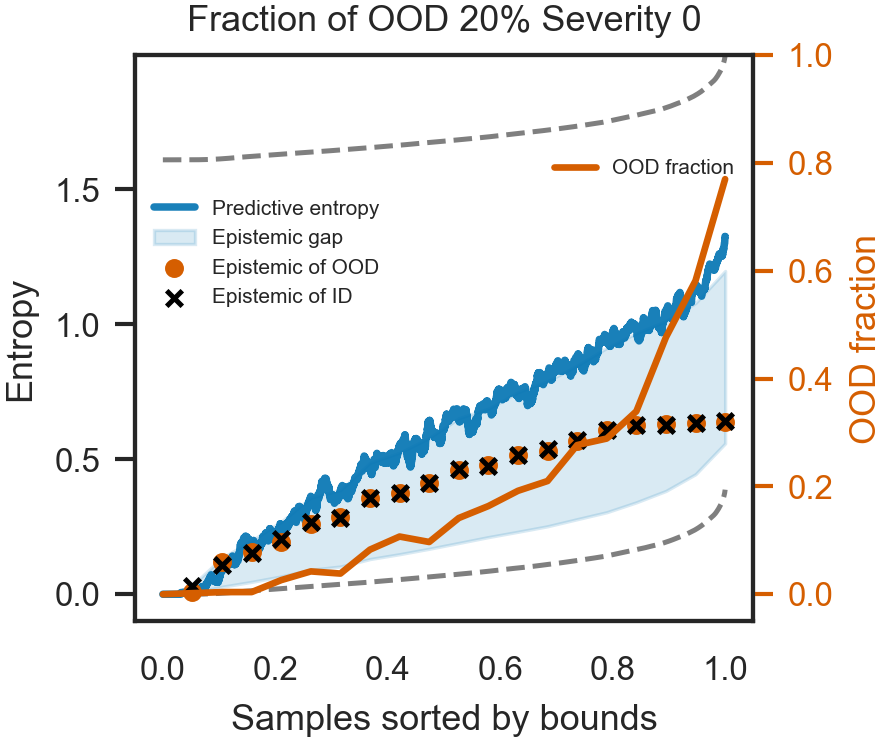

In [9]:
figures_path = averaged_dir / 'figures' / f'bin_{PLOT_NUM_BINS}'
figures_path.mkdir(parents=True, exist_ok=True)

plot_title = (
    f"Fraction of OOD {int(CONFIG['ood_fraction'] * 100)}% "
    f"Severity {CONFIG['cifar10c_severity']}"  # Only relevant for CIFAR10C, but we can keep it in the title for consistency across OOD datasets
)

plot_entropy_and_bounds_with_ood_bins_icml(
    data['entropies'],
    data['lower_bound'],
    data['upper_bound'],
    is_ood=data['is_ood'],
    sort_by=PLOT_SORT_BY,
    aleatoric=data['aleatoric'],
    title=plot_title,
    num_bins=PLOT_NUM_BINS,
    window=PLOT_WINDOW,
    save_path=str(figures_path),
    save_plot=False
)

## 6.1 Plotting with different visualization options
The plot in Figure 1 of the paper was generated with `PLOT_NUM_BINS = 20` and `PLOT_WINDOW = 100`. You can change these values and re-run the plotting cell to see how it affects the visualization.

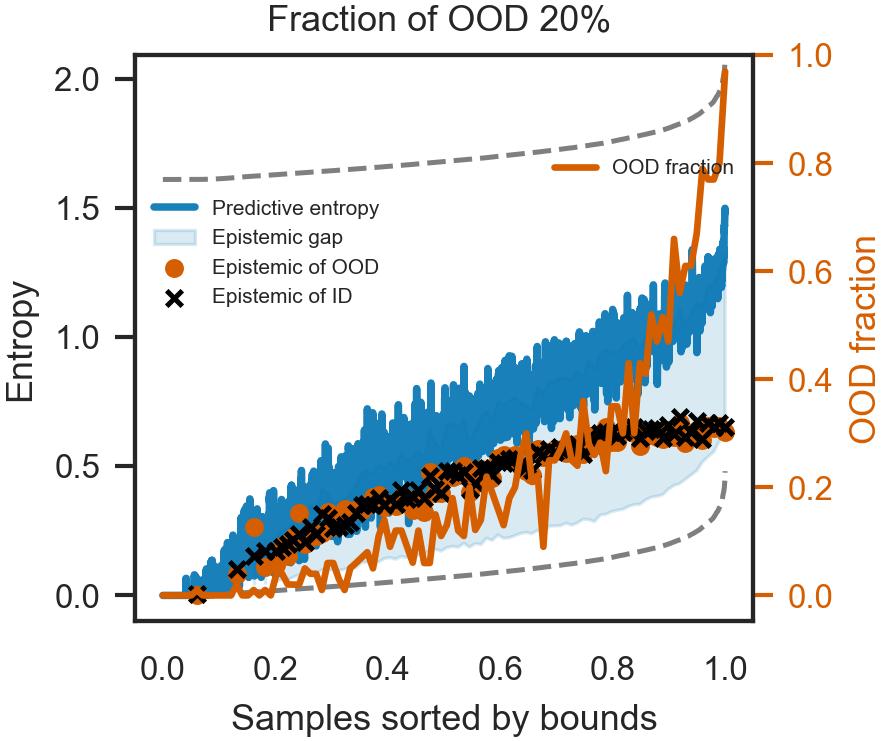

In [10]:
PLOT_NUM_BINS = 100
PLOT_WINDOW = 10

figures_path = averaged_dir / 'figures' / f'bin_{PLOT_NUM_BINS}'
figures_path.mkdir(parents=True, exist_ok=True)

plot_title = (
    f"Fraction of OOD {int(CONFIG['ood_fraction'] * 100)}% "
)

plot_entropy_and_bounds_with_ood_bins_icml(
    data['entropies'],
    data['lower_bound'],
    data['upper_bound'],
    is_ood=data['is_ood'],
    sort_by=PLOT_SORT_BY,
    aleatoric=data['aleatoric'],
    title=plot_title,
    num_bins=PLOT_NUM_BINS,
    window=PLOT_WINDOW,
    save_path=str(figures_path),
    save_plot=False,
)

## 7. ADDITIONAL: Plotting results without performing inference

In order to avoid inference we can directly used the results stored in the corresponding folder. These were run for any combination of OOD fraction and severity (in the case of CIFAR10C).


### Results for 50% of SVHN OOD samples

In [11]:
# Main experimental configuration
CONFIG = {
    'batch_size': 128,
    'num_models': 5,
    'ensemble_type': 'deep',      # supported here: 'deep'
    'data_transformation': 'raw_data',  # supported here: 'raw_data' or 'transf_data'
    'ood_fraction': 0.5,  # any value in [0, 1] is supported
    'ood_dataset': 'svhn',        # 'svhn' or 'cifar10c'
    'cifar10c_corruption': 'gaussian_noise',  # only for cifar10c
    'cifar10c_severity': 0,  # only for cifar10c, any value in [1, 5] is supported
}

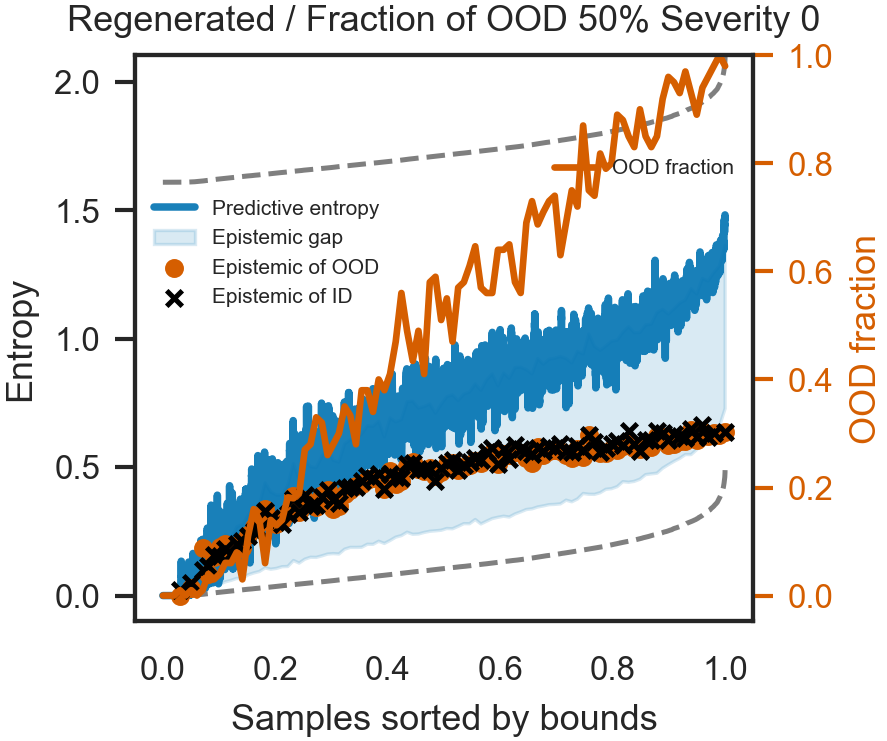

In [12]:
# Example: plot again from already-saved averaged arrays without reevaluating models.
plot_only_dir = build_results_dir(CONFIG, averaged=True)
plot_only_data = np.load(plot_only_dir / 'uncertainty_accuracy_vectors_no_order.npz')
plot_only_figures = plot_only_dir / 'figures' / f'bin_{PLOT_NUM_BINS}'
plot_only_figures.mkdir(parents=True, exist_ok=True)

plot_title = (
    f"Fraction of OOD {int(CONFIG['ood_fraction'] * 100)}% "
    f"Severity {CONFIG['cifar10c_severity']}"  # Only relevant for CIFAR10C, but we can keep it in the title for consistency across OOD datasets
)

plot_entropy_and_bounds_with_ood_bins_icml(
    plot_only_data['entropies'],
    plot_only_data['lower_bound'],
    plot_only_data['upper_bound'],
    is_ood=plot_only_data['is_ood'],
    sort_by=PLOT_SORT_BY,
    aleatoric=plot_only_data['aleatoric'],
    title=f'Regenerated / {plot_title}',
    num_bins=PLOT_NUM_BINS,
    window=PLOT_WINDOW,
    save_path=str(plot_only_figures),
    save_plot=False,
)

### Results for 80% of SVHN OOD samples

In [13]:
# Main experimental configuration
CONFIG = {
    'batch_size': 128,
    'num_models': 5,
    'ensemble_type': 'deep',      # supported here: 'deep'
    'data_transformation': 'raw_data',  # supported here: 'raw_data' or 'transf_data'
    'ood_fraction': 0.8,  # any value in [0, 1] is supported
    'ood_dataset': 'svhn',        # 'svhn' or 'cifar10c'
    'cifar10c_corruption': 'gaussian_noise',  # only for cifar10c
    'cifar10c_severity': 0,  # only for cifar10c, any value in [1, 5] is supported
}

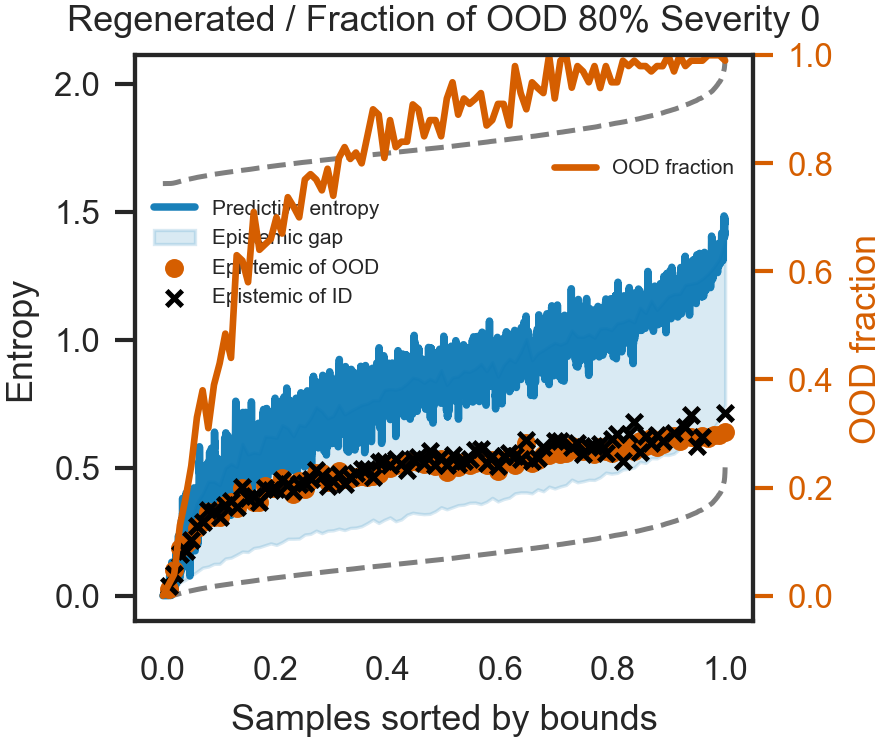

In [14]:
# Example: plot again from already-saved averaged arrays without reevaluating models.
plot_only_dir = build_results_dir(CONFIG, averaged=True)
plot_only_data = np.load(plot_only_dir / 'uncertainty_accuracy_vectors_no_order.npz')
plot_only_figures = plot_only_dir / 'figures' / f'bin_{PLOT_NUM_BINS}'
plot_only_figures.mkdir(parents=True, exist_ok=True)

plot_title = (
    f"Fraction of OOD {int(CONFIG['ood_fraction'] * 100)}% "
    f"Severity {CONFIG['cifar10c_severity']}"  # Only relevant for CIFAR10C, but we can keep it in the title for consistency across OOD datasets
)

plot_entropy_and_bounds_with_ood_bins_icml(
    plot_only_data['entropies'],
    plot_only_data['lower_bound'],
    plot_only_data['upper_bound'],
    is_ood=plot_only_data['is_ood'],
    sort_by=PLOT_SORT_BY,
    aleatoric=plot_only_data['aleatoric'],
    title=f'Regenerated / {plot_title}',
    num_bins=PLOT_NUM_BINS,
    window=PLOT_WINDOW,
    save_path=str(plot_only_figures),
    save_plot=False,
)
